In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
data = pd.read_csv('train.csv')
data.shape

(42000, 785)

In [59]:
data.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [60]:
X = data.drop('label', axis=1)
y = data['label']
X.shape, y.shape

((42000, 784), (42000,))

In [61]:
img = X.iloc[0].values
img.shape
# 784 x 1

(784,)

In [62]:
sq = (int) (np.sqrt(img.shape[0]))
img = img.reshape(sq, sq)

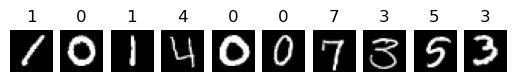

In [63]:
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X.iloc[i].values.reshape(sq, sq), cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_dev, y_test, y_dev = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_dev.shape, y_dev.shape

((29400, 784), (29400,), (6300, 784), (6300,), (6300, 784), (6300,))

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_dev = scaler.transform(X_dev)

In [66]:
X_train = X_train.reshape(X_train.shape[0], sq, sq, 1)
X_test = X_test.reshape(X_test.shape[0], sq, sq, 1)
X_dev = X_dev.reshape(X_dev.shape[0], sq, sq, 1)
X_train.shape, X_test.shape, X_dev.shape

((29400, 28, 28, 1), (6300, 28, 28, 1), (6300, 28, 28, 1))

In [67]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
import tensorflow as tf

In [68]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(sq,sq,1)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [69]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 27, 32)     │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,938 (878.66 KB)

 Trainable params: 224,938 (878.66 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_dev, y_dev))

Epoch 1/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9457 - loss: 0.1799 - val_accuracy: 0.9768 - val_loss: 0.0861
Epoch 2/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9827 - loss: 0.0581 - val_accuracy: 0.9784 - val_loss: 0.0763
Epoch 3/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9872 - loss: 0.0385 - val_accuracy: 0.9844 - val_loss: 0.0523
Epoch 4/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9917 - loss: 0.0273 - val_accuracy: 0.9868 - val_loss: 0.0472
Epoch 5/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9824 - val_loss: 0.1415
Epoch 6/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9940 - loss: 0.0174 - val_accuracy: 0.9852 - val_loss: 0.0627
Epoch 7/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9854 - val_loss: 0.0559
Epoch 8/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9959 - loss: 0.0118 - val_accuracy: 0.

In [71]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9863 - loss: 0.0801
Test Loss: 0.08014950156211853
Test Accuracy: 0.9863492250442505
